# Implementación MobileViT
En este ejercicio se busca emular la red neuronal que aparece en la siguiente figura del documento de MobileViT [1]:

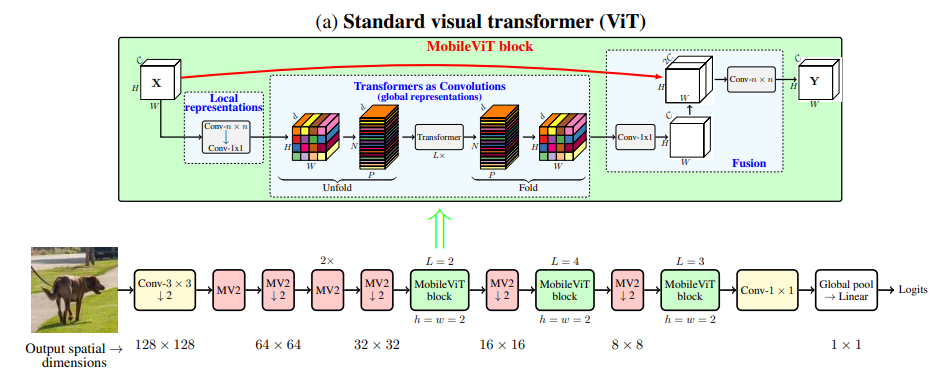

**Figura 1.** Arquitectura del módulo MobileViT.

Para lo que previamente se reproducirá el módulo MobileViT.


In [19]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models.mobilenetv2 import InvertedResidual

## Módulo MobileViT

### Bloques convulocionales

Los bloques convolucionales se emplean en dos partes principales del módulo MobileViT:

- **Representación local**: permiten extraer características locales de la imagen, aprovechando la información espacial de los píxeles vecinos.
- **Fusión**: para combinar y transformar las características obtenidas tras el procesamiento mediante el Transformer.

Estos bloques pueden incorporar técnicas que mejoran el entrenamiento, como:

- **Batch Normalization (BN)**: normaliza las activaciones de las distintas capas, ayudando a estabilizar entrenamiento.
- Funciones de activación **Swish**: introducen no linealidad en la red.

In [20]:
def conv_block(in_channels, out_channels, kernel_size, stride=1, norm=True, act=True):
    """Secuencia de capas: Convulocional, normalizacion, activacion SiLU"""
    padding = "same" if stride == 1 else kernel_size // 2
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=padding, bias=False)]
    if norm:
        layers.append(nn.BatchNorm2d(out_channels))
    if act:
        layers.append(nn.SiLU())
    return nn.Sequential(*layers)

### Operación Unfold

La operación Unfold divide el mapa de características en pequeños patches de tamaño *P = wh*, reorganizándolos para poder procesarlos posteriormente mediante el Transformer.

In [21]:
def unfold(x, ph, pw):
  """ Tensor de entrada [B, d, H, W] --> Tensor de salida [B * P, N, d].
      N: Numero de patches, P:Pixel/Posicion en el patch.
      Interpretación salida:
      1. Indice/Eje I (BxP): Combina el indice del batch y la posicion dentro del patch. Primero aparecen las P posiciones del primer elemento del batch, despues las P posiciones del segundo, etc.
      2. Indice/Eje II  (N): Indice del patch espacial. Para una posicion concreta dentro del patch, contiene los diferentes patches de la imagen.
      3. Indice/Eje III (d): Indice del canal """
  B, d, H, W = x.shape
  nh, nw = H // ph, W // pw
  N = nh * nw
  x = x.reshape(B, d, nh, ph, nw, pw)
  x = x.permute(0, 3, 5, 1, 2, 4)     # B, ph, pw, nh, nw, d
  x = x.reshape(B * ph * pw, N, d)
  return x, (B, d, nh, nw)



### Operación Fold

La operación Fold realiza el proceso inverso a Unfold, reorganizando los patches procesados por el Transformer para reconstruir el mapa de características con su estructura espacial original.

In [22]:
def fold(x, ph, pw, shape):
  """ Tensor de entrada [B * P, N, d] --> Tensor de salida [B, d, H, W]."""
  B, d, nw, nh = shape
  x = x.reshape(B, ph, pw, nh, nw, d)   # Shape devuelto por unfold
  x = x.permute(0, 5, 3, 1, 4, 2)       # B, d, nh, ph, nw, pw
  x = x.reshape(B, d, nh * ph, nw * pw)
  return x

### Bloque MobileViT

Se divide en tres etapas principales:

- **Representación local**: se utilizan capas convolucionales para extraer características locales del mapa de características.

- **Representación global**: las características se reorganizan mediante Unfold en pequeños patches y se procesan mediante L Transformers, permitiendo capturar relaciones entre regiones alejadas de la imagen.

- **Fusión**: mediante una convolución adicional, combina las características locales detalladas con el contexto global obtenido por el Transformer. De este modo, cada posición espacial de la representación puede incorporar información procedente del contexto global de la imagen.

In [23]:
class MobileViTBlock(nn.Module):
  def __init__(self, in_channels, d, depth=2, num_heads=4, ffn_dim=None, conv_ksize=3, patch_size=(2, 2), dropout=0.0):
    super().__init__()
    assert d % num_heads == 0, "d debe ser múltiplo de num_heads"
    self.ph, self.pw = patch_size

    # [1] Representacion local: codifica informacion espacila local (conv nxn)
    #     y proyecta a la dimension de del transformer (conv 1x1)
    self.local_rep = nn.Sequential(
        conv_block(in_channels, in_channels, conv_ksize),
        conv_block(in_channels, d, 1, norm=False, act=False)
    )

    # [2] Representacion global: L bloques Transformer apilados
    transform_layer = nn.TransformerEncoderLayer(
        d_model=d,
        nhead=num_heads,
        dim_feedforward=ffn_dim or 2*d,
        dropout=dropout,
        batch_first=True,
        norm_first=True,
        activation=F.silu
    )
    self.transformers = nn.TransformerEncoder(transform_layer, num_layers=depth, norm=nn.LayerNorm(d), enable_nested_tensor=False)

    # [3] Fusion: Proyección de d a C
    self.proj = conv_block(d, in_channels, 1) #??

    # [3] Fusion: 2C canales -> conv -> C canales
    self.fusion = conv_block(2*in_channels, in_channels, conv_ksize)

  def forward(self, x):
    origianl_x = x
    B, C, H, W = x.shape

    # 1. representacion Local
    x = self.local_rep(x)                   # X_L: B x d x H x W

    # !!. si H o W no son multiplos del tamaño del parche se reescala
    new_h = math.ceil(H / self.ph) * self.ph
    new_w = math.ceil(W / self.pw) * self.pw
    resized = (new_h, new_w) != (H, W)
    if resized:
      x = F.interpolate(x, size=(new_h, new_w), mode="bilinear", align_corners=False)

    # 2. Representacion global
    x, shape = unfold(x, self.ph, self.pw)  # X_U: (B*P) x N x d
    x = self.transformers(x)                # X_G: (B*P) x N x d
    x = fold(x, self.ph, self.pw, shape)    # X_F: B x d x H x W

    if resized:
      x =F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)

    # 3. Fusion
    x = self.proj(x)
    x = torch.cat([origianl_x, x], dim=1)          # B x 2C x H x W
    x = self.fusion(x)               # B x C x H x W
    return x


## Red

En este apartado se construye la red mostrada en la **Figura 1**, utilizando como componente principal el bloque MobileViT descrito anteriormente. Para definir la arquitectura y los parámetros de la red, se toma como referencia la configuración del modelo **MobileViT-S** proporcionada por los autores en el repositorio oficial [1].

[1] Apple Machine Learning Research, *ml-cvnets*, configuración de MobileViT-S. [Repositorio de GitHub](https://github.com/apple-aiml-research/ml-cvnets/blob/main/cvnets/models/classification/config/mobilevit.py)

In [24]:

# Omitidos
CONFIG_S = {
    "stem_channels": 16,
    "layer1": {"out_channels": 32, "num_blocks": 1, "stride": 1},
    "layer2": {"out_channels": 64, "num_blocks": 3, "stride": 2},
    "layer3": {"out_channels": 96, "d": 144, "ffn_dim": 288, "depth": 2},
    "layer4": {"out_channels": 128, "d": 192, "ffn_dim": 384, "depth": 4},
    "layer5": {"out_channels": 160, "d": 240, "ffn_dim": 480, "depth": 3},
    "last_layer_exp_factor": 4,
}

class MobileViT(nn.Module):
  def __init__(self, num_classes=2, config=CONFIG_S, num_heads=4, patch_size=(2, 2), expand=4, dropout=0.0):
    super().__init__()
    c = config["stem_channels"]

    self.features = nn.Sequential()

    # Conv-3x3 down-2
    self.features.add_module("conv_stem", conv_block(3, c, 3, stride=2))

    #layer1 y layer2: bloques MV2, el responsable del stride es el primero de cada capa
    for name in ("layer1", "layer2"):
      layer_config = config[name]
      blocks = []
      for i in range(layer_config["num_blocks"]):
        blocks.append(InvertedResidual(
            c if i==0 else layer_config["out_channels"], layer_config["out_channels"],
            layer_config["stride"] if i == 0 else 1, expand))
      c = layer_config["out_channels"]
      self.features.add_module(name, nn.Sequential(*blocks))

    #layer3, layer4, layer5: MV2 down-2, MobileViT
    for name in ("layer3", "layer4", "layer5"):
      layer_config = config[name]
      self.features.add_module(name, nn.Sequential(
          InvertedResidual(c, layer_config["out_channels"], 2, expand),
          MobileViTBlock(layer_config["out_channels"], layer_config["d"],
                         depth=layer_config["depth"], num_heads=num_heads,
                         ffn_dim=layer_config["ffn_dim"], conv_ksize=3, patch_size=patch_size, dropout=dropout)
      ))
      c = layer_config["out_channels"]

    # Conv-1x1 expansion de canales
    last = c * config["last_layer_exp_factor"]
    self.features.add_module("conv_last", conv_block(c, last, 1))

    # Global pool + Linear
    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(last, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x



## Preparar Dataset

Se emplea el conjunto de datos **STL-10**, que contiene 10 clases diferentes, entre ellas la clase *perro*. Para este ejercicio, las etiquetas se reasignan a un problema de clasificación binaria: perro (índice original 5) y no perro (resto de clases).

Las transformaciones se aplican de forma perezosa (*lazy*), es decir, cuando el *DataLoader* solicita un elemento del conjunto de datos. Al incluir transformaciones aleatorias, cada muestra puede obtener una transformación diferente en cada acceso, proporcionando así un **aumento de datos dinámico** durante el entrenamiento.

Durante la evaluación no se emplean transformaciones aleatorias ni aumento de datos.

Para el entrenamiento se utiliza el 90 % del conjunto de entrenamiento, mientras que el 10 % restante se reserva para la evaluación.

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torchvision.datasets import STL10
from torchvision import transforms

MEAN, STD = (0.4408, 0.4279, 0.3867), (0.2682, 0.2610, 0.2686)
dog_idx = 5                                   # STL10.classes.index("dog")
def to_binary(y):                             # 1 = perro, 0 = resto
    return int(y == dog_idx)

def get_transforms(img_size=128, mean=MEAN, std=STD, strong_aug=False):
  # Entrenamiento: aumento de datos dinamico, cada epoca observara una variante de la foto

  if strong_aug:
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.35, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.TrivialAugmentWide(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), value=0)
    ])
  else:
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.5, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

  # Validación / Test: determinista
  eval_tf = transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
      transforms.Normalize(mean, std)
  ])
  return train_tf, eval_tf


def get_datasets(root="stl10_raw", img_size=128, val_frac=0.1, seed=0, mean=MEAN, std=STD, strong_aug=False):
  train_tf, eval_tf = get_transforms(img_size, mean, std, strong_aug=strong_aug)

  train_full = STL10(root, split="train", download=True, transform=train_tf, target_transform=to_binary)
  val_full   = STL10(root, split="train", download=True, transform=eval_tf,  target_transform=to_binary)
  test_ds    = STL10(root, split="test",  download=True, transform=eval_tf,  target_transform=to_binary)
  assert train_full.classes[dog_idx] == "dog", "DOG_IDX no coincide con las clases de STL-10"

  # Divide 'train_full' en train (90%) y val (10%) de forma estratificada (conserva proporcion de perros en ambos conjuntos)
  # e instancia dos Subset de PyTorch.
  is_dog = train_full.labels == dog_idx
  tr_idx, va_idx = train_test_split(np.arange(len(is_dog)), test_size=0.1, stratify=is_dog, random_state=seed)
  train_ds, val_ds = Subset(train_full, tr_idx), Subset(val_full, va_idx)

  counts = np.bincount(is_dog[tr_idx].astype(int), minlength=2)
  return train_ds, val_ds, test_ds, counts

## Entrenamiento

Se divide en tres operaciones principales:

- **Entrenamiento:** se utiliza el conjunto de entrenamiento para calcular la pérdida, obtener los gradientes y actualizar los parámetros de la red.

- **Validación:** se evalúa el modelo sobre el 10 % del conjunto de datos reservado para validación. En esta fase no se actualizan los parámetros de la red ni se aplica aumento de datos. Llevada a cabo al fin de cada época.

- **Test:** una vez finalizado el entrenamiento, se evalúa el modelo sobre el conjunto de test de STL-10, que no ha sido utilizado durante el entrenamiento ni la validación, para obtener una estimación final de su capacidad de generalización.

In [26]:
import contextlib
import csv
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

DOG_IDX = 1

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

### Evaluación

Para evaluar el rendimiento del modelo se utilizan la **pérdida (*loss*)**, la **matriz de confusión**, *accuracy*, *precision*, *recall* y *F1-score*. Estas métricas permiten analizar el rendimiento general y los distintos tipos de errores cometidos por el modelo.

La **matriz de confusión** recoge las predicciones del modelo en función de la clase real. En nuestro problema de clasificación binaria, la clase positiva corresponde a **perro**:

|  | Predicción: Perro | Predicción: No perro |
|---|---:|---:|
| **Real: Perro** | TP | FN |
| **Real: No perro** | FP | TN |

Donde:

- **TP (*True Positive*):** un perro correctamente identificado.
- **TN (*True Negative*):** un no-perro correctamente identificado.
- **FP (*False Positive*):** un no-perro clasificado como perro.
- **FN (*False Negative*):** un perro clasificado como no-perro.

A partir de estos valores se calculan las siguientes métricas:

- **Loss:** se utiliza la entropía cruzada (*cross-entropy*) para medir el error entre las predicciones y las etiquetas reales. Un valor menor indica un mejor ajuste.

- **Accuracy (exactitud):** proporción de muestras clasificadas correctamente:
  $$
  \mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$

- **Precision (valor predictivo positivo, PPV):** proporción de las muestras clasificadas como perro que realmente son perros:
  $$
  \mathrm{Precision} = \frac{TP}{TP + FP}
  $$

- **Recall (sensibilidad o tasa de verdaderos positivos, TPR):** proporción de los perros reales que son correctamente identificados:
  $$
  \mathrm{Recall} = \frac{TP}{TP + FN}
  $$

- **F1-score (medida F1):** media armónica entre *precision* y *recall*, proporcionando un equilibrio entre ambas:
  $$
  F1 = 2\frac{\mathrm{Precision}\cdot\mathrm{Recall}}
  {\mathrm{Precision}+\mathrm{Recall}}
  $$


In [27]:
@torch.no_grad()
def evaluate(model, loader, device, dog_idx=DOG_IDX):
  model.eval()
  loss_sum, n = 0.0, 0
  tp = fp = fn = tn = 0

  for x, y in loader:
    x, y = x.to(device), y.to(device)
    logits = model(x)

    # Calculos para la perdida
    loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
    n += y.numel()

    # Calculos para la matriz de confusión
    pred_dog = logits.argmax(dim=1) == dog_idx
    true_dog = y == dog_idx
    tp += (pred_dog & true_dog).sum().item()
    fp += (pred_dog & ~true_dog).sum().item()
    fn += (~pred_dog & true_dog).sum().item()
    tn += (~pred_dog & ~true_dog).sum().item()

  # Metricas para clasificacion binaria
  accuracy = (tp + tn) / n
  precision = tp / max(tp + fp, 1)
  recall = tp / max(tp + fn, 1)
  f1 = 2 * precision * recall / max(precision + recall, 1e-9)
  return {"loss": loss_sum / n, "acc": accuracy, "precision": precision,
          "recall":recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn, "tn": tn}

### Entrenamiento

#### 1. Optimización del Flujo de Datos (Data Pipeline)

*   **`pin_memory=True`**: Cuando se entrena en GPU, activar esta opción en el `DataLoader` bloquea la memoria RAM de la CPU asignada a los lotes. Esto permite una transferencia de datos directa y mucho más rápida mediante **Direct Memory Access (DMA)** hacia la memoria de la GPU (`cuda`), reduciendo el cuello de botella del procesador.

---

#### 2. Función de Pérdida con Pesos de Clase

Dado que el dataset presenta un desbalanceo de clases (pocas muestras de la clase positiva **perro**), se utiliza **`torch.nn.CrossEntropyLoss`** configurando el argumento `weight`.

*   **Cálculo de pesos**: Los pesos se asignan de forma inversamente proporcional a las frecuencias de cada clase.
$$w_c = \frac{N_{\text{total}}}{K \times N_c}$$
*   **Efecto**: Penaliza con mayor severidad los errores cometidos en la clase minoritaria (perro), forzando al modelo a prestarle más atención y evitando que se sesgue hacia la clase mayoritaria.

---

#### 3. Estrategia de Optimización y Regularización

*   **Optimizador AdamW**: Versión de Adam que implementa decaimiento por pesos o **`weight_decay`**. En lugar de sumar la penalización directamente al gradiente, AdamW aplica la regularización \(L_2\) directamente sobre los pesos del modelo, para prevenir el sobreajuste (*overfitting*).

*   **Planificador del Learning Rate (Scheduler)**: Para estabilizar la convergencia, se utiliza un `SequentialLR` que combina una fase de calentamiento seguido de un descenso cosenoidal:

```python
if 0 < warmup < epochs:
    # Combinación secuencial: subida gradual inicial (Warmup) + decaimiento cosenoidal
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        [
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs - warmup)
        ],
        milestones=[warmup]
    )
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
```

---

#### 4. Estabilización Numérica y Eficiencia (AMP & Gradient Clipping)

##### Mezcla de Precisión Automática (AMP)
Para acelerar el entrenamiento y ahorrar memoria en la GPU, se gestiona el casteo de precisión mediante un gestor de contexto condicional. Esto permite ejecutar ciertas operaciones en precisión de 16 bits (`float16`) en lugar de 32 bits (`float32`):

```python
# Contexto de casting automático de precisión si AMP está activado
ctx = torch.autocast(device_type="cuda") if use_amp else contextlib.nullcontext()
```
Al usar AMP, los gradientes muy pequeños pueden volverse cero (underflow), por lo que se requiere acompañar este contexto con un `torch.cuda.amp.GradScaler` para escalar la pérdida antes de calcular los gradientes.

##### **Gradient Clipping (Recorte de Gradientes)**
Su función principal es prevenir el problema de los gradientes explosivos, un fenómeno común en redes profundas o recurrentes (ej. Transformers) donde los gradientes crecen tanto durante la retropropagación que desestabilizan el entrenamiento o causan valores `NaN` / `Inf`.

*   **Funcionamiento**:
    1. Calcula la norma global (\(L_2\)) de todos los gradientes de los parámetros del modelo:
$\text{norma\_total} = \sqrt{\sum_{i} \Vert{}\mathbf{g}_i\Vert{}_2^2}$
       *(donde $\mathbf{g}_i$ es el gradiente de cada parámetro).*
    2. Compara la `norma\_total` con el umbral fijado (`max_norm = 1.0`):
        * Si \(\text{norma\_total} \le 1.0\), no hace nada.
        * Si \(\text{norma\_total} > 1.0\), escala proporcionalmente todos los gradientes para que la norma total quede reducida exactamente a \(1.0\):
$$\mathbf{g}_{\text{nuevo}} = \mathbf{g} \times \frac{\text{max_norm}}{\text{norma_total}}$$
*   **Propiedad clave**: No altera la dirección del gradiente (la dirección del aprendizaje se mantiene intacta), solo reduce su magnitud cuando es demasiado grande.

---

#### 5. Registro de Checkpointing

*   **Historial de Métricas**: Se guarda un registro con las métricas calculadas por época tanto para el conjunto de entrenamiento como de validación. Se usa posteriormente para su representación.

*   **Selección del Mejor Modelo**: El criterio principal para guardar el estado óptimo del modelo  es la métrica **F1-score** en el conjunto de validación. Al buscar maximizar el balance armónico entre precisión y exhaustividad, nos aseguramos de guardar la época que mejor resuelve el desbalanceo de clases.

In [28]:
def train(model, traind_ds, val_ds, counts, epochs=40, batch_size=64, lr=1e-3, weight_decay=0.01,
          warmup=2, workers=4, out="runs/dog", seed=0, device=None):
  # ===================
  # [1] Configuracion
  # ===================

  # Semillas para reproducir aleatoriedad del entrenamiento
  torch.manual_seed(seed)
  np.random.seed(seed)

  # Asignar dispositivo, por defecto si no se especifica
  device = device or get_device()

  # Objeto de la ruta de salida y creacion del directorio pertinente
  out = Path(out)
  out.mkdir(parents=True, exist_ok=True)

  # Mover el modelo a la memoria del  dispositivo ( GPU o CPU )
  model = model.to(device)
  print(f"dispositivo: {device} | imágenes de train por clase [no perro, perro]: {counts.tolist()}")

  # ======================================
  # [2] DataLoaders y Funcion de Perdida
  # ======================================

  # En caso de usar GPU activaremos pin_memory
  pin = device.type == "cuda"

  # Loader de entrenamiento: mezcla muestras, descarta lote incompleto
  train_loader = DataLoader(traind_ds, batch_size=batch_size, shuffle=True,
                            num_workers=workers, pin_memory=pin, drop_last=True)

  # Loader de validacion: sin orden aleatorio
  val_loader = DataLoader(val_ds, batch_size, num_workers=workers, pin_memory=pin)

  # Pesos para la funcion de perdida
  weights = torch.tensor(
    counts.sum() / (len(counts) * counts),
    dtype=torch.float32,
    device=device
  )

  loss_f = nn.CrossEntropyLoss(weight=weights)

  # ============================================================
  # [3] Optimizador y Planifiador de Learning Rate (Scheduler)
  # ============================================================

  # Optimizador AdamW, con regularizacion por decaimiento de pesos
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

  # Schedule: configuracion de la tasa de aprendizaje
  if 0 < warmup < epochs:
      # Combinación secuencial: subida gradual inicial (Warmup) + decaimiento cosenoidal
      scheduler = torch.optim.lr_scheduler.SequentialLR(
          optimizer,
          [
              torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup),
              torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs - warmup)
          ],
          milestones=[warmup]
      )
  else:
      scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

  # =====================================
  # [4] AMP: precisión mixta automática
  # =====================================

  # AMP (float 16) solo si se usa GPU
  use_amp = device.type == "cuda"

  # Escalador de gradientes. Para evitar underflow
  scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

  # ===============================================
  # [5] Bucle principal de entrenamiento (epocas)
  # ===============================================

  history, best_f1 = [], -1.0

  for epoch in range(1, epochs + 1):
    t0 = time.time()      # Cronomentro para medir duracion de la epoca
    model.train()         # Modelo en modo entrenamiento
    loss_sum, n = 0.0, 0  # Contadores para calculo de perdida media

    # Bucle por lotes (batches) de entrenamiento
    for x, y in train_loader:
      x, y = x.to(device), y.to(device)   # Datos de entrada y etiquetas al dispositvo actual

      # Contexto de casting automático de precisión si AMP está activado
      ctx = torch.autocast(device_type="cuda") if use_amp else contextlib.nullcontext()

      # --> FORWARD PASS
      with ctx:
        loss = loss_f(model(x), y)

      # --> BACKWARD PASS Y OPTIMIZACION
      optimizer.zero_grad(set_to_none=True) # Liberar gradientes anteriore
      scaler.scale(loss).backward()         # Calcular gradientes, escalados
      scaler.unscale_(optimizer)            # Desescalara antes del clip o recorte de gradientes

      nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Recortar gradientes
      scaler.step(optimizer)                            # Actualizar los parametros de la red
      scaler.update()                                   # Actualizar el escalador

      # Actualizar contadores
      loss_sum += loss.item() * len(y)
      n += len(y)

    lr_now = optimizer.param_groups[0]["lr"]  # Learning rate actual
    scheduler.step()                          # Actaulizar scheduler

    # ==========================================
    # [6] Validacion y seguimiento de métricas
    # ==========================================

    # Evaluar el modelo
    val = evaluate(model, val_loader, device)

    # Dicionario con los resultados de la epoca
    rec = {
        "epoch": epoch,
        "train_loss": loss_sum / n,
        "val_loss": val["loss"],
        "val_acc": val["acc"],
        "val_precision": val["precision"],
        "val_recall": val["recall"],
        "val_f1": val["f1"],
        "lr": lr_now,
        "seconds": time.time() - t0
    }
    history.append(rec)

    # Imprimir por consola resultados
    print(
        f"época {epoch:3d}/{epochs} | train_loss {rec['train_loss']:.4f} | "
        f"val_loss {rec['val_loss']:.4f} | acc {val['acc']:.3f} | "
        f"P {val['precision']:.3f} R {val['recall']:.3f} F1 {val['f1']:.3f} | "
        f"lr {lr_now:.2e} | {rec['seconds']:.0f}s"
    )

    # Guardar checkpoint si supera al anterior
    if val["f1"] > best_f1:
        best_f1 = val["f1"]
        torch.save(
            {"model": model.state_dict(), "epoch": epoch, "val": val},
            out / "best.pt"
        )

  # =======================
  # [7] Guardar historial
  # =======================
  with open(out / "history.csv", "w", newline="") as f:
      writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
      writer.writeheader()
      writer.writerows(history)

  print(f"mejor F1 en validación: {best_f1:.3f} | checkpoint: {out / 'best.pt'}")
  return history



### Test y Resultados

---

#### 1. Función de Test (`test`)

La función `test` automatiza la carga del mejor estado del modelo, realiza la inferencia sobre el dataset de prueba, imprime las métricas de rendimiento junto con la matriz de confusión estructurada y exporta un informe en formato JSON.

---
#### 2. Visualización de Historial (`plot_history`)

Para diagnosticar el comportamiento del modelo a lo largo del tiempo, la función `plot_history` genera dos gráficos paralelos utilizando `matplotlib`:

1.  **Gráfico de Pérdida (*Loss*)**: Permite identificar fenómenos de sobreajuste (*overfitting*) (si la pérdida de entrenamiento baja pero la de validación empieza a subir) o subajuste (*underfitting*) (si ambas curvas se estabilizan en valores altos).
2.  **Gráfico de Métricas de Validación**: Monitoriza la evolución de la *precisión*, el *recall* y el *F1-score* enfocados específicamente en la clase de interés (perro). Esto ayuda a visualizar cómo interactúa el balance armónico a medida que avanzan las épocas.


In [29]:
def test(model, test_ds, ckpt_path, batch_size=64, workers=4, device=None):
  # ===========================================
  # [1] Cargar checkpoint y configurar modelo
  # ===========================================
  device = device or get_device()
  ckpt = torch.load(ckpt_path, map_location=device)
  model.load_state_dict(ckpt["model"])
  model.to(device)

  # ===========================
  # [2] Dataset y evaluacion
  # ===========================
  loader = DataLoader(test_ds, batch_size, num_workers=workers, pin_memory=device.type == "cuda")
  res = evaluate(model, loader, device)

  # ==============================================
  # 3. Imprimir resultados y matriz de confusion
  # ==============================================

  print(f"checkpoint de la época {ckpt['epoch']}")
  print(
      f"test | acc {res['acc']:.3f} | precisión {res['precision']:.3f} | "
      f"recall {res['recall']:.3f} | F1 {res['f1']:.3f}"
  )

  print("matriz de confusión (filas = real, columnas = predicho)")
  print(
      f"              no perro   perro\n"
      f"  no perro    {res['tn']:8d} {res['fp']:7d}\n"
      f"  perro       {res['fn']:8d} {res['tp']:7d}"
  )

  # =======================
  # 4. Guardar resultados
  # =======================
  with open(Path(ckpt_path).with_name("results.json"), "w") as f:
    json.dump({"best_epoch": ckpt["epoch"], "val": ckpt["val"], "test": res}, f, indent=2)
  return res


def plot_history(history, save_to=None):
  import matplotlib.pyplot as plt
  epochs = [h["epoch"] for h in history]
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
  ax1.plot(epochs, [h["train_loss"] for h in history], label="train")
  ax1.plot(epochs, [h["val_loss"] for h in history], label="val")
  ax1.set_xlabel("época")
  ax1.set_ylabel("pérdida")
  ax1.legend()
  ax2.plot(epochs, [h["val_precision"] for h in history], label="precisión")
  ax2.plot(epochs, [h["val_recall"] for h in history], label="recall")
  ax2.plot(epochs, [h["val_f1"] for h in history], label="F1")
  ax2.set_xlabel("época")
  ax2.set_title("validación (clase perro)")
  ax2.legend()
  fig.tight_layout()
  if save_to:
    fig.savefig(save_to, dpi=120)
  return fig



## Ejecucion

dispositivo: cuda | imágenes de train por clase [no perro, perro]: [4050, 450]


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


época   1/100 | train_loss 0.6910 | val_loss 0.6970 | acc 0.498 | P 0.115 R 0.600 F1 0.193 | lr 1.00e-05 | 35s
época   2/100 | train_loss 0.6700 | val_loss 0.6033 | acc 0.638 | P 0.180 R 0.740 F1 0.290 | lr 5.50e-05 | 30s
época   3/100 | train_loss 0.6240 | val_loss 0.5816 | acc 0.622 | P 0.186 R 0.820 F1 0.303 | lr 1.00e-04 | 30s
época   4/100 | train_loss 0.6198 | val_loss 0.4575 | acc 0.694 | P 0.222 R 0.820 F1 0.349 | lr 1.00e-04 | 31s
época   5/100 | train_loss 0.6105 | val_loss 0.4506 | acc 0.756 | P 0.184 R 0.420 F1 0.256 | lr 9.99e-05 | 30s
época   6/100 | train_loss 0.5923 | val_loss 0.4484 | acc 0.730 | P 0.236 R 0.760 F1 0.360 | lr 9.98e-05 | 30s
época   7/100 | train_loss 0.6057 | val_loss 0.5348 | acc 0.662 | P 0.201 R 0.800 F1 0.321 | lr 9.96e-05 | 30s
época   8/100 | train_loss 0.5812 | val_loss 0.4589 | acc 0.698 | P 0.194 R 0.640 F1 0.298 | lr 9.94e-05 | 30s
época   9/100 | train_loss 0.5864 | val_loss 0.4502 | acc 0.736 | P 0.227 R 0.680 F1 0.340 | lr 9.91e-05 | 30s
é

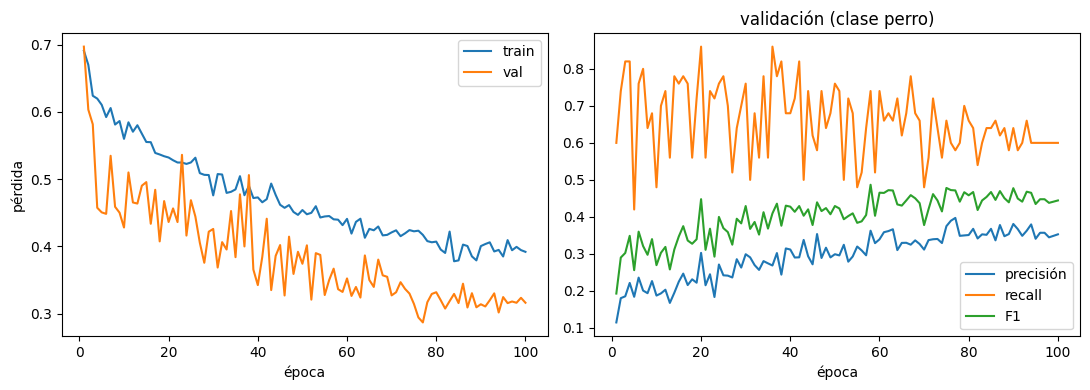

In [30]:
# 1. Datos
train_ds, val_ds, test_ds, counts = get_datasets(img_size=128, strong_aug=True)

# 2. Modelo
model = MobileViT(num_classes=2, dropout=0.1)

# 3. Entrenamiento (guarda el mejor checkpoint en runs/dog/best.pt)
history = train(model, train_ds, val_ds, counts, epochs=100, batch_size=64, lr=1e-4, workers=4, weight_decay=0.05)

# 4. Histórico
plot_history(history, save_to="runs/dog/curves.png")

# 5. Test (con el mejor checkpoint)
results = test(model, test_ds, "runs/dog/best.pt", workers=4)